In [1]:
! pip install QuantLib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 20.7 MB/s eta 0:00:00


In [40]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import datetime
import QuantLib as ql
import pandas_datareader.data as web

# Options

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

class MarketSimulator:
    """Quantitative engine for financial market simulation."""
    def __init__(self, S0, T, r, sigma, simulations=10000, steps=252):
        self.S0 = S0
        self.T = T
        self.r = r
        self.sigma = sigma
        self.simulations = simulations
        self.steps = steps
        self.dt = T / steps

    def generate_paths(self):
        """Generate the path matrix using geometric Brownian motion."""
        paths = np.zeros((self.steps + 1, self.simulations))
        paths[0] = self.S0
        for t in range(1, self.steps + 1):
            Z = np.random.standard_normal(self.simulations)
            paths[t] = paths[t-1] * np.exp((self.r - 0.5 * self.sigma**2) * self.dt + self.sigma * np.sqrt(self.dt) * Z)
        return paths

    def _generate_greeks_grid(self):
        class_name = self.__class__.__name__.lower()
        opt_type = getattr(self, 'option_type', '').lower()

        is_put = ('put' in class_name) or ('put' in opt_type)
        is_call = ('call' in class_name) or ('call' in opt_type)
        is_vanilla = ('european' in class_name) or ('vanilla' in class_name) or (class_name in ['europeancalloption', 'europeanputoption'])

        if is_vanilla and (is_call or is_put):
            s_grid = np.linspace(self.S0 * 0.5, self.S0 * 1.5, 100)
            d1 = (np.log(s_grid / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
            d2 = d1 - self.sigma * np.sqrt(self.T)

            gamma_curve = norm.pdf(d1) / (s_grid * self.sigma * np.sqrt(self.T))
            vega_curve = s_grid * norm.pdf(d1) * np.sqrt(self.T)

            if is_call:
                delta_curve = norm.cdf(d1)
                theta_curve = -(s_grid * norm.pdf(d1) * self.sigma) / (2 * np.sqrt(self.T)) - self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
                rho_curve = self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(d2)
                price_curve = s_grid * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
            else:
                delta_curve = norm.cdf(d1) - 1.0
                theta_curve = -(s_grid * norm.pdf(d1) * self.sigma) / (2 * np.sqrt(self.T)) + self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(-d2)
                rho_curve = -self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(-d2)
                price_curve = self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - s_grid * norm.cdf(-d1)

            return s_grid, list(delta_curve), list(gamma_curve), list(vega_curve), list(theta_curve), list(rho_curve), list(price_curve)

        else:
            s_grid = np.linspace(self.S0 * 0.7, self.S0 * 1.3, 30)
            delta_curve, gamma_curve, vega_curve, theta_curve, rho_curve = [], [], [], [], []
            price_curve = []

            orig_S0 = self.S0
            orig_sigma = self.sigma
            orig_r = self.r
            orig_T = self.T
            orig_sim = self.simulations
            self.simulations = 1000

            for s in s_grid:
                self.S0 = s
                p_base, _ = self.price()
                price_curve.append(p_base)
                ds = max(0.01, 0.01 * s)
                self.S0 = s + ds
                p_up, _ = self.price()
                self.S0 = s - ds
                p_down, _ = self.price()
                self.S0 = s

                delta_curve.append((p_up - p_down) / (2 * ds))
                gamma_curve.append((p_up - 2 * p_base + p_down) / (ds ** 2))

                dvol = 0.01
                self.sigma = orig_sigma + dvol
                p_v_up, _ = self.price()
                self.sigma = orig_sigma
                vega_curve.append((p_v_up - p_base) / dvol)

                dt = 0.005
                if self.T > dt:
                    self.T = orig_T - dt
                    p_t_down, _ = self.price()
                    self.T = orig_T
                    theta_curve.append((p_t_down - p_base) / dt)
                else:
                    theta_curve.append(0.0)

                dr = 0.001
                self.r = orig_r + dr
                p_r_up, _ = self.price()
                self.r = orig_r
                rho_curve.append((p_r_up - p_base) / dr)


            self.S0 = orig_S0
            self.sigma = orig_sigma
            self.r = orig_r
            self.T = orig_T
            self.simulations = orig_sim

            return s_grid, delta_curve, gamma_curve, vega_curve, theta_curve, rho_curve, price_curve


    def plot_greeks_dashboard(self):
        """Generate a 6-panel dashboard, including stochastic trajectories and dynamic payoff."""
        s_grid, deltas, gammas, vegas, thetas, rhos, prices = self._generate_greeks_grid()

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        greeks_data = [
            (deltas, 'Delta (Δ)', '#D69E2E'),
            (gammas, 'Gamma (Γ)', '#4A5568'),
            (vegas, 'Vega (ν)', '#805AD5'),
            (thetas, 'Theta (Θ)', '#E53E3E')
        ]

        for i, (curve, name, color) in enumerate(greeks_data):
            ax = axes[i]
            ax.plot(s_grid, curve, color=color, lw=2.5, label=name)
            ax.axvline(getattr(self, 'K', self.S0), color='#A0AEC0', linestyle=':', lw=1.5)
            ax.set_title(f"{name} Profile", fontweight='bold', color='#1A365D')
            ax.set_xlabel("Spot Price (S)")
            ax.set_ylabel("Value")
            ax.legend(loc='upper left')
            ax.grid(True, alpha=0.3)

        ax_paths = axes[4]
        paths = self.generate_paths()
        time_grid = np.linspace(0, self.T, self.steps + 1)
        ax_paths.plot(time_grid, paths[:, :50], alpha=0.35, lw=1)
        ax_paths.axhline(self.S0 * np.exp(self.r * self.T), color='black', linestyle='--', lw=1.5, label='Fwd Price')

        if hasattr(self, 'barrier'):
            ax_paths.axhline(self.barrier, color='#E53E3E', linestyle='-.', lw=1.8, label=f'Barrier ({self.barrier})')

        ax_paths.set_title("Monte Carlo Price Paths", fontweight='bold', color='#1A365D')
        ax_paths.set_xlabel("Maturity (Years)")
        ax_paths.set_ylabel("Sottostante ($)")
        ax_paths.legend(loc='upper left')
        ax_paths.grid(True, alpha=0.3)

        ax_payoff = axes[5]
        payoff_curve = self._calculate_pure_payoff(s_grid)

        ax_payoff.plot(s_grid, payoff_curve, color='#718096', linestyle='--', lw=2, label='Static Payoff at T')
        ax_payoff.plot(s_grid, prices, color='#2F855A', linestyle='-', lw=2.5, label='Option Price (Monte Carlo)')
        ax_payoff.axvline(getattr(self, 'K', self.S0), color='#A0AEC0', linestyle=':', lw=1.5)

        ax_payoff.set_title("Option Value & Payoff Curve", fontweight='bold', color='#1A365D')
        ax_payoff.set_xlabel("Spot Price (S)")
        ax_payoff.set_ylabel("Value ($)")
        ax_payoff.legend(loc='upper left')
        ax_payoff.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def _calculate_pure_payoff(self, s_grid):
        """Fallback method for Vanilla options."""
        strike = getattr(self, 'K', self.S0)
        class_name = self.__class__.__name__.lower()
        opt_type = getattr(self, 'option_type', '').lower()
        is_call = ('call' in class_name) or ('call' in opt_type)

        if is_call:
            return np.maximum(s_grid - strike, 0)
        return np.maximum(strike - s_grid, 0)

## Vanilla European Call and Put Options

In [78]:
class EuropeanCallOption(MarketSimulator):
    """Vanilla European Call Option"""
    def __init__(self, S0, T, r, sigma, K, simulations=50000, steps=252):
        super().__init__(S0, T, r, sigma, simulations, steps)
        self.K = K
        self.option_type = 'call'

    def price(self):
        """Standard method required by the simulator to calculate the Monte Carlo price"""
        paths = self.generate_paths()
        S_T = paths[-1]
        MC_payoff = np.maximum(S_T - self.K, 0)
        MC_price = np.exp(-self.r * self.T) * np.mean(MC_payoff)
        return MC_price, paths

    def full_report(self):
        MC_price, paths = self.price()
        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        BS_price = self.S0 * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)

        delta = norm.cdf(d1)
        gamma = norm.pdf(d1) / (self.S0 * self.sigma * np.sqrt(self.T))
        vega = self.S0 * norm.pdf(d1) * np.sqrt(self.T)
        theta = -(self.S0 * norm.pdf(d1) * self.sigma) / (2 * np.sqrt(self.T)) - self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
        rho = self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(d2)

        print("="*60)
        print("                EUROPEAN CALL (VANILLA)              ")
        print("="*60)
        print(f"Market Inputs:  S0={self.S0}, K={self.K}, T={self.T}Y, r={self.r*100}%, sigma={self.sigma*100}%")
        print("-"*60)
        print(f"Black-Scholes Price : {BS_price:.5f} USD")
        print(f"Monte Carlo Price   : {MC_price:.5f} USD ({self.simulations} simulations)")
        print(f"Absolute Error      : {abs(BS_price - MC_price):.5f} USD")
        print("-"*60)
        print(f"Delta           : {delta:.4f} (Portfolio Replication Ratio: {delta*100:.1f}%)")
        print(f"Gamma           : {gamma:.4f} (Delta Acceleration / Curvature)")
        print(f"Vega            : {vega:.4f} (Sensitivity to 100% Volatility change)")
        print(f"Theta           : {theta:.4f} (Annual Time Decay)")
        print(f"Rho             : {rho:.4f} (Interest Rate Sensitivity)")
        print("="*60)
        self.plot_greeks_dashboard()

        return {"BS_Price": BS_price, "MC_Price": MC_price, "Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta, "Rho": rho}

In [79]:
class EuropeanPutOption(MarketSimulator):
    """Vanilla European Put Option"""
    def __init__(self, S0, T, r, sigma, K, simulations=50000, steps=252):
        super().__init__(S0, T, r, sigma, simulations, steps)
        self.K = K
        self.option_type = 'put'

    def price(self):
        """Core pricing method for put options using stochastic simulation."""
        paths = self.generate_paths()
        S_T = paths[-1]
        MC_payoff = np.maximum(self.K - S_T, 0)
        MC_price = np.exp(-self.r * self.T) * np.mean(MC_payoff)
        return MC_price, paths

    def full_report(self):
        MC_price, paths = self.price()

        d1 = (np.log(self.S0 / self.K) + (self.r + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)
        BS_price = self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - self.S0 * norm.cdf(-d1)

        delta = norm.cdf(d1) - 1.0
        gamma = norm.pdf(d1) / (self.S0 * self.sigma * np.sqrt(self.T))
        vega = self.S0 * norm.pdf(d1) * np.sqrt(self.T)
        theta = -(self.S0 * norm.pdf(d1) * self.sigma) / (2 * np.sqrt(self.T)) + self.r * self.K * np.exp(-self.r * self.T) * norm.cdf(-d2)
        rho = -self.K * self.T * np.exp(-self.r * self.T) * norm.cdf(-d2)

        print("="*60)
        print("                EUROPEAN PUT (VANILLA)              ")
        print("="*60)
        print(f"Market Inputs:  S0={self.S0}, K={self.K}, T={self.T}Y, r={self.r*100}%, sigma={self.sigma*100}%")
        print("-"*60)
        print(f"Black-Scholes Price : {BS_price:.5f} USD")
        print(f"Monte Carlo Price   : {MC_price:.5f} USD ({self.simulations} simulations)")
        print(f"Absolute Error      : {abs(BS_price - MC_price):.5f} USD")
        print("-"*60)
        print(f"Delta           : {delta:.4f} (Portfolio Replication Ratio: {delta*100:.1f}%)")
        print(f"Gamma           : {gamma:.4f} (Identical to Call option curvature)")
        print(f"Vega            : {vega:.4f} (Sensitivity to 100% Volatility change)")
        print(f"Theta           : {theta:.4f} (Annual Time Decay)")
        print(f"Rho             : {rho:.4f} (Interest Rate Sensitivity)")
        print("="*60)

        self.plot_greeks_dashboard()

        return {"BS_Price": BS_price, "MC_Price": MC_price, "Delta": delta, "Gamma": gamma, "Vega": vega, "Theta": theta, "Rho": rho}

## Barrier Options

In [80]:
class BarrierOption(MarketSimulator):
    def __init__(self, S0, T, r, sigma, K, barrier, barrier_direction="down", barrier_style="out", option_type="call", simulations=10000, steps=252):
        super().__init__(S0, T, r, sigma, simulations, steps)
        self.K = K
        self.barrier = barrier
        self.direction = barrier_direction.lower()
        self.style = barrier_style.lower()
        self.option_type = option_type.lower()

    def price(self):
        paths = self.generate_paths()
        if self.direction == "down":
            has_hit = np.any(paths < self.barrier, axis=0)
        else:
            has_hit = np.any(paths > self.barrier, axis=0)

        if self.option_type == "call":
            payoffs = np.maximum(paths[-1] - self.K, 0)
        else:
            payoffs = np.maximum(self.K - paths[-1], 0)

        if self.style == "out":
            payoffs[has_hit] = 0
        else:
            payoffs[~has_hit] = 0

        price = np.exp(-self.r * self.T) * np.mean(payoffs)
        std_err = np.std(payoffs) / np.sqrt(self.simulations)
        return price, std_err

    def _calculate_pure_payoff(self, s_grid):
        """Calculate the static payoff assuming immediate settlement/activation at the spot price."""
        if self.option_type == "call":
            base = np.maximum(s_grid - self.K, 0)
        else:
            base = np.maximum(self.K - s_grid, 0)

        if self.direction == "down":
            invalid = s_grid < self.barrier
        else:
            invalid = s_grid > self.barrier

        if self.style == "out":
            base[invalid] = 0
        else:
            base[~invalid] = 0
        return base

    def full_report(self):
        p, err = self.price()
        s_grid, deltas, gammas, vegas, thetas, rhos, prices = self._generate_greeks_grid()
        idx = np.abs(s_grid - self.S0).argmin()

        print("="*65)
        print(f"       BARRIER OPTION ({self.direction.upper()}-AND-{self.style.upper()} {self.option_type.upper()})")
        print("="*65)
        print(f" Market Inputs: S0={self.S0}, K={self.K}, Barrier={self.barrier}, T={self.T}Y, r={self.r*100}%")
        print("-"*65)
        print(f" Monte Carlo Price   : {p:.5f} USD (± {err:.5f})")
        print("="*65 + "\n")

## Asian Options

In [81]:
class AsianOption(MarketSimulator):
    def __init__(self, S0, T, r, sigma, K, option_type="call", simulations=10000, steps=252):
        super().__init__(S0, T, r, sigma, simulations, steps)
        self.K = K
        self.option_type = option_type.lower()

    def price(self):
        paths = self.generate_paths()
        avg_prices = np.mean(paths, axis=0)
        if self.option_type == "call":
            payoffs = np.maximum(avg_prices - self.K, 0)
        else:
            payoffs = np.maximum(self.K - avg_prices, 0)
        price = np.exp(-self.r * self.T) * np.mean(payoffs)
        std_err = np.std(payoffs) / np.sqrt(self.simulations)
        return price, std_err

    def _calculate_pure_payoff(self, s_grid):
        if self.option_type == "call":
            return np.maximum(s_grid - self.K, 0)
        return np.maximum(self.K - s_grid, 0)

    def full_report(self):
        p, err = self.price()
        s_grid, deltas, gammas, vegas, thetas, rhos, prices = self._generate_greeks_grid()

        print("="*65)
        print(f"                ASIAN ARITHMETIC {self.option_type.upper()}")
        print("="*65)
        print(f" Monte Carlo Price   : {p:.5f} USD")
        print("="*65 + "\n")

## Digital Options

In [82]:
class DigitalOption(MarketSimulator):
    def __init__(self, S0, T, r, sigma, K, cash_payoff=1.0, option_type="call", simulations=10000, steps=252):
        super().__init__(S0, T, r, sigma, simulations, steps)
        self.K = K
        self.cash_payoff = cash_payoff
        self.option_type = option_type.lower()

    def price(self):
        paths = self.generate_paths()
        if self.option_type == "call":
            payoffs = np.where(paths[-1] > self.K, self.cash_payoff, 0.0)
        else:
            payoffs = np.where(paths[-1] < self.K, self.cash_payoff, 0.0)
        price = np.exp(-self.r * self.T) * np.mean(payoffs)
        std_err = np.std(payoffs) / np.sqrt(self.simulations)
        return price, std_err

    def _calculate_pure_payoff(self, s_grid):
        if self.option_type == "call":
            return np.where(s_grid > self.K, self.cash_payoff, 0.0)
        return np.where(s_grid < self.K, self.cash_payoff, 0.0)

    def full_report(self):
        p, err = self.price()
        s_grid, deltas, gammas, vegas, thetas, rhos, prices = self._generate_greeks_grid()

        print("="*65)
        print(f"                DIGITAL CASH-OR-NOTHING {self.option_type.upper()}")
        print("="*65)
        print(f" Monte Carlo Price   : {p:.5f} USD")
        print("="*65 + "\n")

# Swaps

In [83]:
class QuantLibMultiCurve:
    """It constructs stable QuantLib yield curves for pricing swaps (IRS).
    It uses short-term deposit rates and swap rates for medium- to long-term maturities."""

    def __init__(self, currency="USD"):
        self.currency = currency.upper()
        self.curve = None
        today = datetime.date.today()
        self.eval_date = ql.Date(today.day, today.month, today.year)

    def fetch_and_build(self):
        ql.Settings.instance().evaluationDate = self.eval_date
        if self.currency == "USD":
            tickers = ["DTB3", "DGS1", "DGS2", "DGS3", "DGS5", "DGS7", "DGS10"]
            calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
            settlement_days = 2
            sw_floating_index = ql.USDLibor(ql.Period(3, ql.Months))
            sw_frequency = ql.Semiannual
            sw_day_count = ql.Thirty360(ql.Thirty360.BondBasis)
        elif self.currency == "EUR":
            tickers = ["IRTBS301EZM156N", "IRLTLT01DEM156N"]
            calendar = ql.TARGET()
            settlement_days = 2
            sw_floating_index = ql.Euribor(ql.Period(6, ql.Months))
            sw_frequency = ql.Annual
            sw_day_count = ql.Thirty360(ql.Thirty360.BondBasis)
        else:
            raise ValueError("Currency Not Supported. Use 'USD' or 'EUR'.")

        live_data = {}

        try:
            df = web.DataReader(tickers,"fred",datetime.date.today() - datetime.timedelta(days=60),datetime.date.today(),)
            df_clean = df.dropna()

            if df_clean.empty:
                raise ValueError("No FRED Data Available.")

            last_valid = df_clean.iloc[-1] / 100.0

            if self.currency == "USD":
                dati_live = {"3M": last_valid["DTB3"], "1Y": last_valid["DGS1"], "2Y": last_valid["DGS2"], "3Y": last_valid["DGS3"],
                             "5Y": last_valid["DGS5"], "7Y": last_valid["DGS7"],"10Y": last_valid["DGS10"],}
            else:
                r_short = last_valid["IRTBS301EZM156N"]
                r_long = last_valid["IRLTLT01DEM156N"]
                live_data = {"3M": r_short, "1Y": r_short + (r_long - r_short) * 0.1, "2Y": r_short + (r_long - r_short) * 0.2,
                             "3Y": r_short + (r_long - r_short) * 0.3, "5Y": r_short + (r_long - r_short) * 0.5, "7Y": r_short + (r_long - r_short) * 0.7,
                             "10Y": r_long,}
            print(f"Data for {self.currency} successfully extracted.")

        except Exception as e:
            print(
                f"FRED is temporarily offline. Structured fallback is active for {self.currency}."
            )
            if self.currency == "USD":
                live_data = {"3M": 0.0450,"1Y": 0.0455,"2Y": 0.0460,"3Y": 0.0465,"5Y": 0.0475,"7Y": 0.0480,"10Y": 0.0490,}
            else:
                live_data = {"3M": 0.0280,"1Y": 0.0290,"2Y": 0.0300,"3Y": 0.0310,"5Y": 0.0325,"7Y": 0.0335,"10Y": 0.0350,}

        helpers = []

        quote_3m = ql.SimpleQuote(live_data["3M"])
        helpers.append(
            ql.DepositRateHelper(
                ql.QuoteHandle(quote_3m),
                ql.Period(3, ql.Months),
                settlement_days,
                calendar,
                ql.ModifiedFollowing,
                True,
                ql.Actual360(),
            )
        )

        maturities = ["1Y", "2Y", "3Y", "5Y", "7Y", "10Y"]
        for s in maturities:
            years = int(s[:-1])
            quote = ql.SimpleQuote(live_data[s])

            helper = ql.SwapRateHelper(
                ql.QuoteHandle(quote),
                ql.Period(years, ql.Years),
                calendar,
                sw_frequency,
                ql.ModifiedFollowing,
                sw_day_count,
                sw_floating_index,
            )
            helpers.append(helper)

        self.curve = ql.PiecewiseLogCubicDiscount(
            self.eval_date, helpers, ql.Actual365Fixed()
        )
        self.curve.enableExtrapolation()

    def get_zero_rate(self, years):
        target_date = self.eval_date + ql.Period(int(round(years * 365)), ql.Days)
        return self.curve.zeroRate(
            target_date, ql.Actual365Fixed(), ql.Continuous
        ).rate()

    def get_forward_rate(self, t1, t2):
        d1 = self.eval_date + ql.Period(int(round(t1 * 365)), ql.Days)
        d2 = self.eval_date + ql.Period(int(round(t2 * 365)), ql.Days)
        return self.curve.forwardRate(
            d1, d2, ql.Actual365Fixed(), ql.Continuous
        ).rate()

## Interest Rate Swap (IRS)

In [84]:
class InterestRateSwap:
  """Plain Vanilla Interest Rate Swap (IRS) (Payer or Receiver). Exchanges a fixed rate for a floating rate."""

  def __init__(self, nominal, maturity, fixed_rate, curve: QuantLibMultiCurve):
    self.nominal = nominal
    self.T = int(maturity)
    self.fixed_rate = fixed_rate
    self.curve = curve

  def price(self, side="payer"):
    npv_fixed = 0.0
    npv_floating = 0.0

    for t in range(1, self.T + 1):
      r_spot = self.curve.get_zero_rate(t)
      discount_factor = np.exp(-r_spot * t)
      cash_flow_fixed = self.nominal * self.fixed_rate
      npv_fixed += cash_flow_fixed * discount_factor

      forward_rate = self.curve.get_forward_rate(t - 1, t)
      cash_flow_floating = self.nominal * forward_rate
      npv_floating += cash_flow_floating * discount_factor

    swap_npv = ((npv_floating - npv_fixed) if side.lower() == "payer" else (npv_fixed - npv_floating))
    sum_df = sum(np.exp(-self.curve.get_zero_rate(t) * t) for t in range(1, self.T + 1))
    fair_swap_rate = npv_floating / (self.nominal * sum_df)

    return {"Swap Net Present Value": swap_npv,"Fixed Leg Net Present Value": npv_fixed,
            "Floating Leg Net Present Value": npv_floating, "Fair Swap Rate": fair_swap_rate}

  def full_report(self, side="payer"):
    res = self.price(side=side)

    print("="*65)
    print(f"       INTEREST RATE SWAP ({side.upper()})")
    print("="*65)
    print(f" Contract Maturity : {self.T} Years")
    print(f" Notional Principal: {self.nominal:,.2f} {self.curve.currency}")
    print(f" Fixed Leg Rate    : {self.fixed_rate*100:.4f}%")
    print(f" Index Curve       : QuantLib MultiCurve ({self.curve.currency})")
    print("-"*65)
    print(f" Fixed Leg NPV     : {res['Fixed Leg Net Present Value']:,.2f} {self.curve.currency}")
    print(f" Floating Leg NPV  : {res['Floating Leg Net Present Value']:,.2f} {self.curve.currency}")
    print("-"*65)
    print(f" SWAP NET VALUE    : {res['Swap Net Present Value']:+,.2f} {self.curve.currency}")
    print(f" FAIR SWAP RATE    : {res['Fair Swap Rate']*100:.4f}% (Par Rate)")
    print("="*65)
    return res

## Credit Default Swap (CDS)

In [85]:
class CreditDefaultSwap:
  """Single-Name Credit Default Swap (CDS).
  Estimate the fair spread in basis points (bps) and the value of the protection using the continuous Hazard Rate model (Intensity Model)."""

  def __init__(self, nominal, maturity, recovery_rate, hazard_rate, curve: QuantLibMultiCurve):
    self.nominal = nominal
    self.T = maturity
    self.R = recovery_rate
    self.lam = hazard_rate
    self.curve = curve

  def price(self):
    fair_spread_annuo = (1 - self.R) * self.lam
    fair_spread_bps = fair_spread_annuo * 10000
    r = self.curve.get_zero_rate(self.T)
    protection_leg = self.nominal * (1 - self.R) * (self.lam / (self.lam + r)) * (1 - np.exp(-(self.lam + r) * self.T))

    return {"Fair Spread Bps": fair_spread_bps, "Protection Leg Value": protection_leg, "Discount Rate": r}

  def full_report(self):
    res = self.price()

    print("="*65)
    print("           CREDIT DEFAULT SWAP")
    print("="*65)
    print(f" Contract Maturity : {self.T} Years")
    print(f" Notional Principal: {self.nominal:,.2f} {self.curve.currency}")
    print(f" Recovery Rate (R) : {self.R*100:.2f}%")
    print(f" Hazard Rate (λ)   : {self.lam*100:.4f}% (Constant Intensity)")
    print("-"*65)
    print(f" Protection Leg NPV: {res['Protection Leg Value']:,.2f} {self.curve.currency}")
    print(f" Risk-Free Discount: {res['Discount Rate']*100:.4f}%")
    print("-"*65)
    print(f" FAIR CDS SPREAD   : {res['Fair Spread Bps']:.2f} bps")
    print("="*65)
    print(" Status: Credit risk premium calibrated using continuous-hazard model.\n")
    return res

## Cross Currency Swap (CSS)

In [86]:
class CrossCurrencySwap:
  """Cross-Currency Interest Rate Swap (CCS).
  Exchanges principal and interest in two different currencies (e.g., EUR and USD)."""

  def __init__(self,nominal_eur,fx_spot_eurusd,maturity,rate_eur,rate_usd,curve_eur: QuantLibMultiCurve,curve_usd: QuantLibMultiCurve,):
    self.nominal_eur = nominal_eur
    self.fx_spot = fx_spot_eurusd
    self.nominal_usd = nominal_eur * fx_spot_eurusd
    self.T = int(maturity)
    self.rate_eur = rate_eur
    self.rate_usd = rate_usd
    self.curve_eur = curve_eur
    self.curve_usd = curve_usd

  def price(self, reporting_currency="EUR"):
    npv_eur_leg = 0.0
    npv_usd_leg = 0.0

    for t in range(1, self.T + 1):
      df_eur = np.exp(-self.curve_eur.get_zero_rate(t) * t)
      npv_eur_leg += (self.nominal_eur * self.rate_eur) * df_eur

      df_usd = np.exp(-self.curve_usd.get_zero_rate(t) * t)
      npv_usd_leg += (self.nominal_usd * self.rate_usd) * df_usd

    df_eur_T = np.exp(-self.curve_eur.get_zero_rate(self.T) * self.T)
    df_usd_T = np.exp(-self.curve_usd.get_zero_rate(self.T) * self.T)

    npv_eur_leg += self.nominal_eur * df_eur_T
    npv_usd_leg += self.nominal_usd * df_usd_T

    if reporting_currency.upper() == "EUR":
      npv_usd_leg_in_eur = npv_usd_leg / self.fx_spot
      total_npv = npv_eur_leg - npv_usd_leg_in_eur
    elif reporting_currency.upper() == "USD":
      npv_eur_leg_in_usd = npv_eur_leg * self.fx_spot
      total_npv = npv_eur_leg_in_usd - npv_usd_leg
    else:
      raise ValueError("Reporting currency ammessa: 'EUR' o 'USD'.")

    return {"Total CSS Net Present Value": total_npv, "Reporting Currency": reporting_currency.upper(),
            "Net Present Value EUR Leg": npv_eur_leg, "Net Present Value USD Leg": npv_usd_leg}
  def full_report(self, reporting_currency="EUR"):
    res = self.price(reporting_currency=reporting_currency)

    print("="*65)
    print("            CROSS CURRENCY SWAP")
    print("="*65)
    print(f" Contract Maturity : {self.T} Years")
    print(f" Notional EUR Leg  : {self.nominal_eur:,.2f} EUR")
    print(f" Notional USD Leg  : {self.nominal_usd:,.2f} USD")
    print(f" FX Spot Rate      : {self.fx_spot:.4f} (EURUSD)")
    print(f" Fixed Rate EUR    : {self.rate_eur*100:.2f}%")
    print(f" Fixed Rate USD    : {self.rate_usd*100:.2f}%")
    print("-"*65)
    print(f" NPV EUR Leg (CCY) : {res['Net Present Value EUR Leg']:,.2f} EUR")
    print(f" NPV USD Leg (CCY) : {res['Net Present Value USD Leg']:,.2f} USD")
    print("-"*65)
    print(f" TOTAL CCS NPV     : {res['Total CSS Net Present Value']:+,.2f} {reporting_currency}")
    print("="*65)
    print(f" Status: Cross-currency basis risk valued in {reporting_currency}.\n")
    return res

# Test

FRED is temporarily offline. Structured fallback is active for USD.
FRED is temporarily offline. Structured fallback is active for EUR.
                EUROPEAN CALL (VANILLA)              
Market Inputs:  S0=100.0, K=100.0, T=1.0Y, r=5.0%, sigma=20.0%
------------------------------------------------------------
Black-Scholes Price : 10.45058 USD
Monte Carlo Price   : 10.55369 USD (10000 simulations)
Absolute Error      : 0.10311 USD
------------------------------------------------------------
Delta           : 0.6368 (Portfolio Replication Ratio: 63.7%)
Gamma           : 0.0188 (Delta Acceleration / Curvature)
Vega            : 37.5240 (Sensitivity to 100% Volatility change)
Theta           : -6.4140 (Annual Time Decay)
Rho             : 53.2325 (Interest Rate Sensitivity)


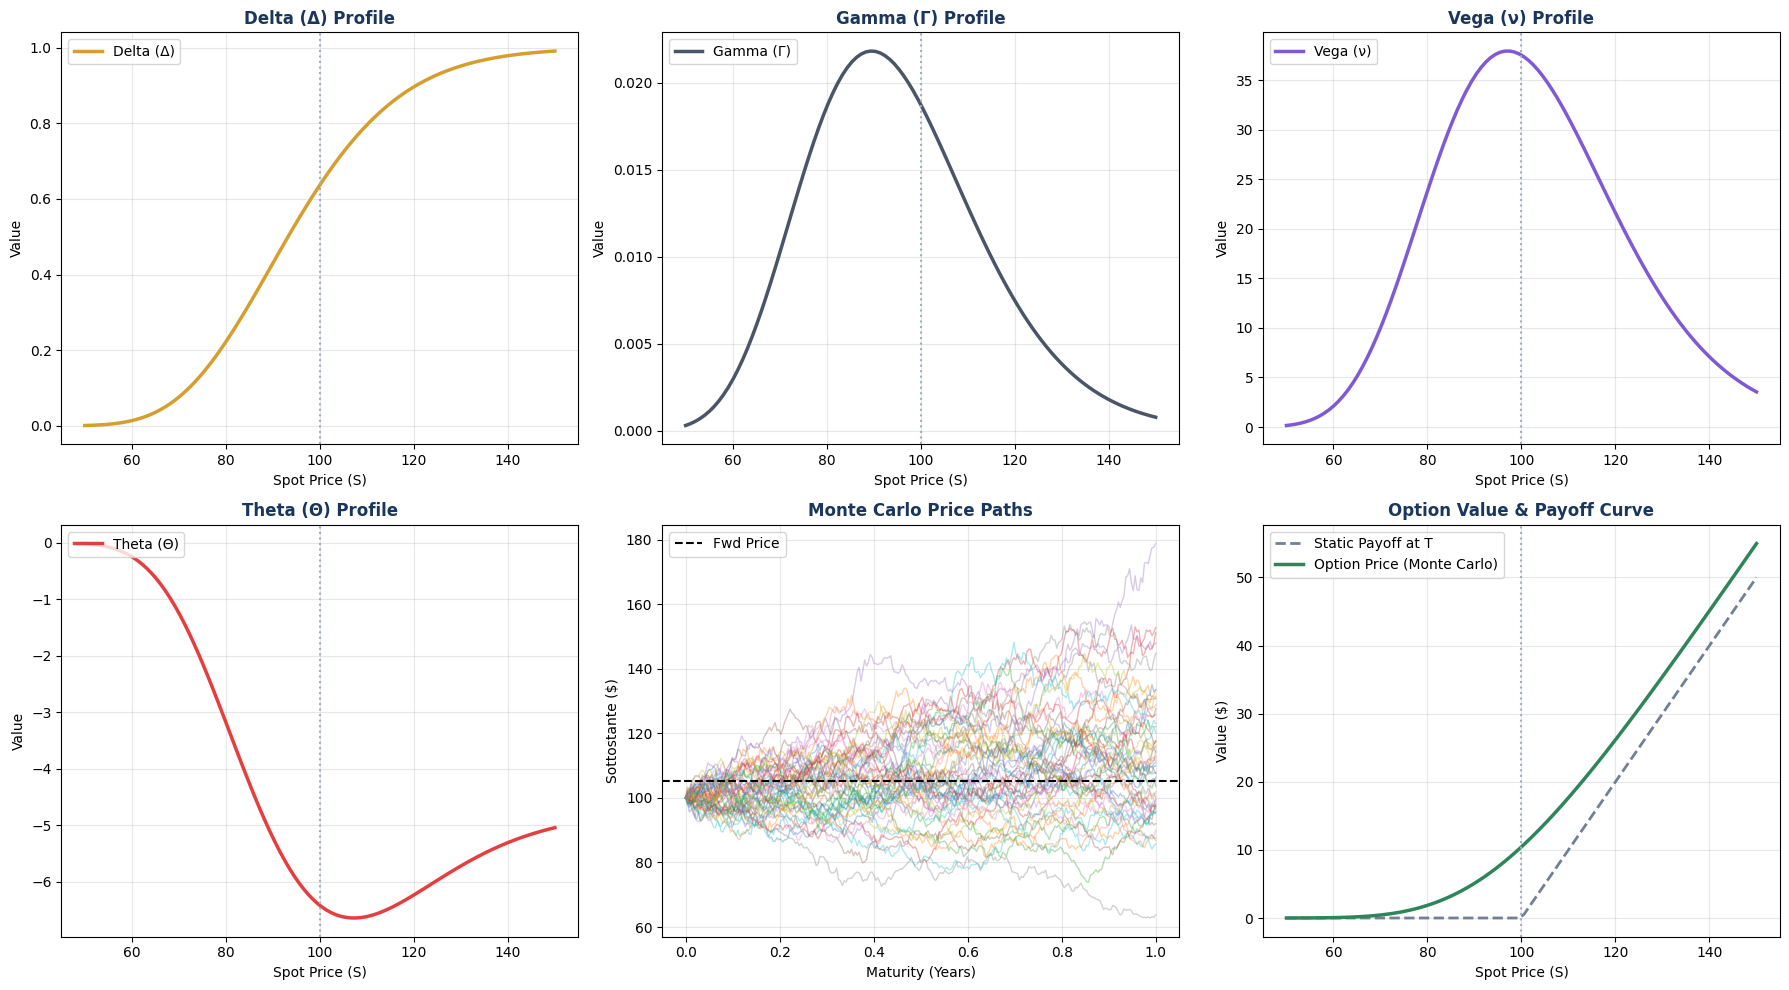

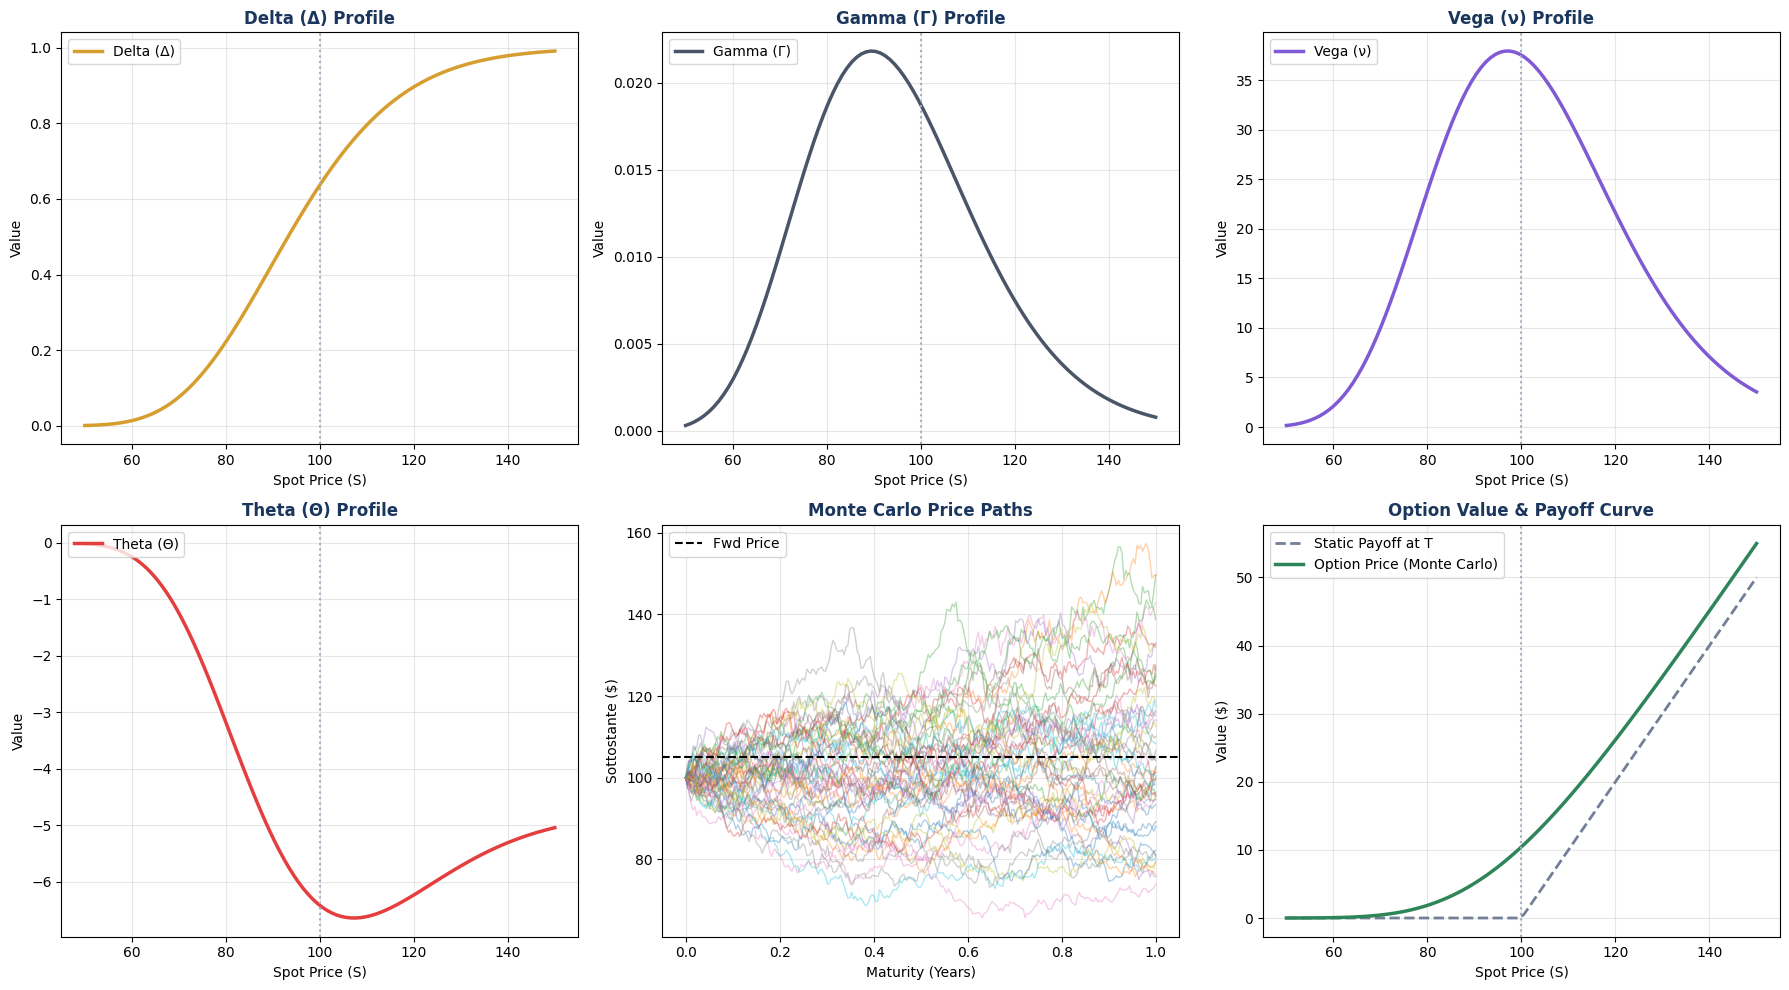

                EUROPEAN PUT (VANILLA)              
Market Inputs:  S0=100.0, K=100.0, T=1.0Y, r=5.0%, sigma=20.0%
------------------------------------------------------------
Black-Scholes Price : 5.57353 USD
Monte Carlo Price   : 5.48339 USD (10000 simulations)
Absolute Error      : 0.09013 USD
------------------------------------------------------------
Delta           : -0.3632 (Portfolio Replication Ratio: -36.3%)
Gamma           : 0.0188 (Identical to Call option curvature)
Vega            : 37.5240 (Sensitivity to 100% Volatility change)
Theta           : -1.6579 (Annual Time Decay)
Rho             : -41.8905 (Interest Rate Sensitivity)


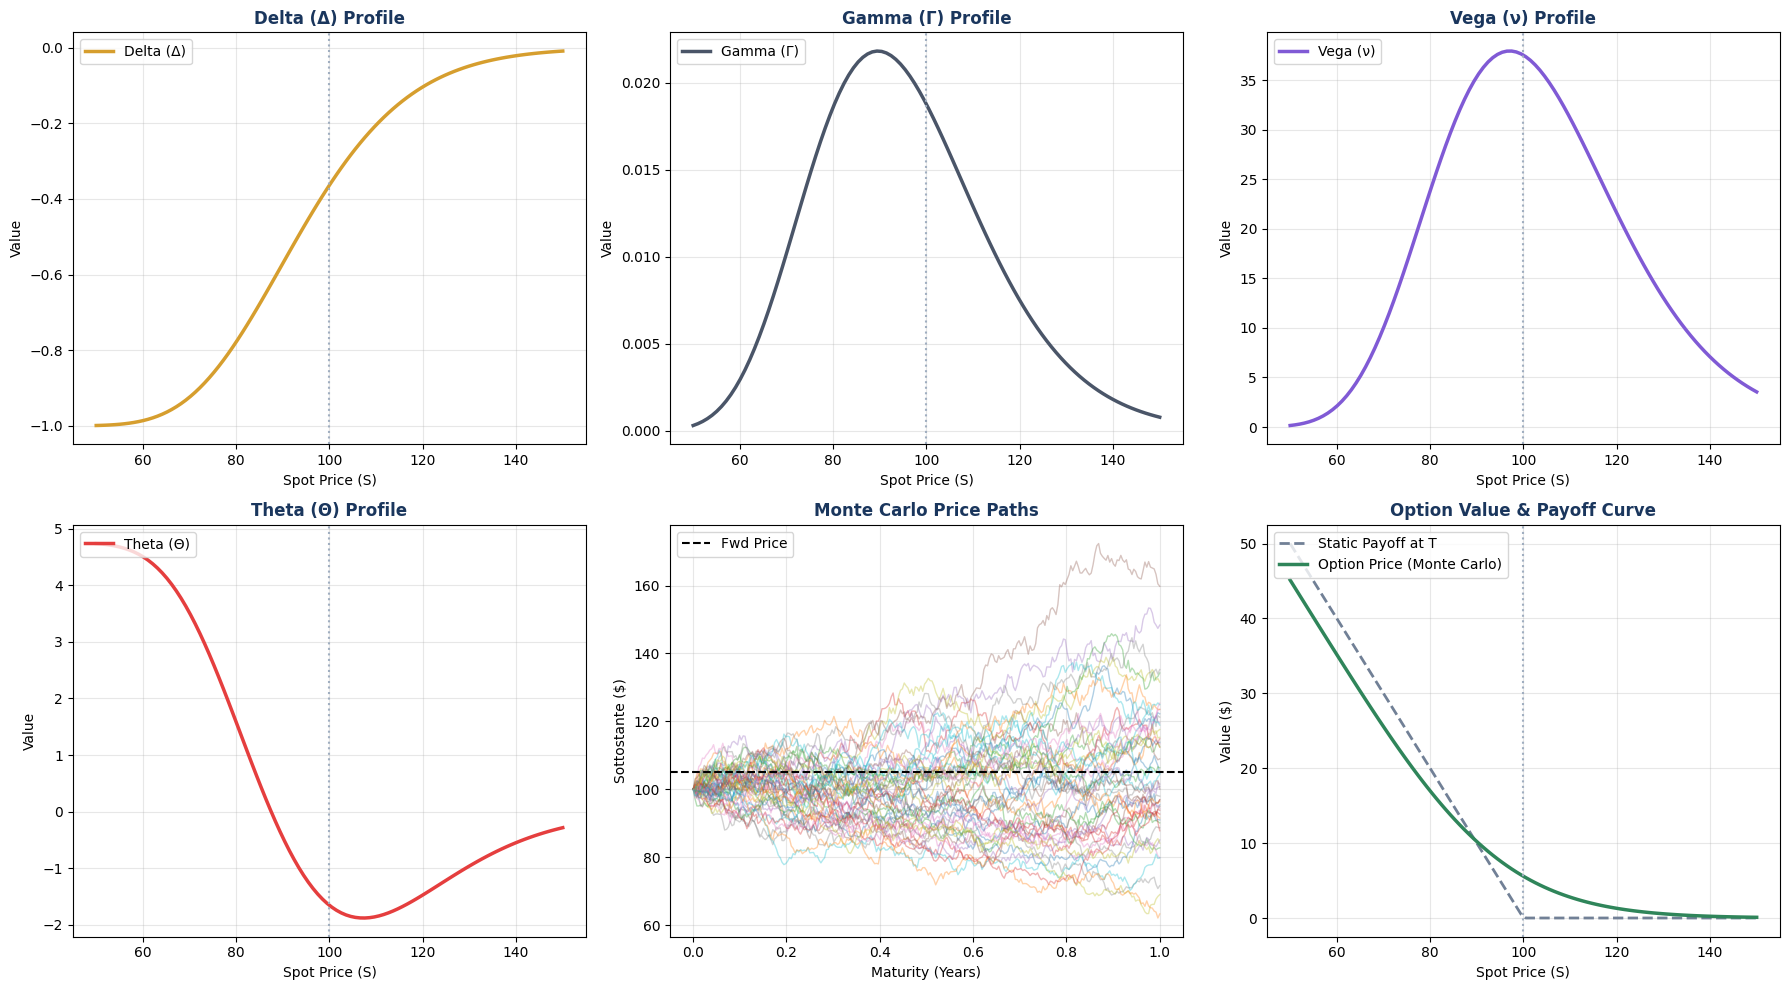

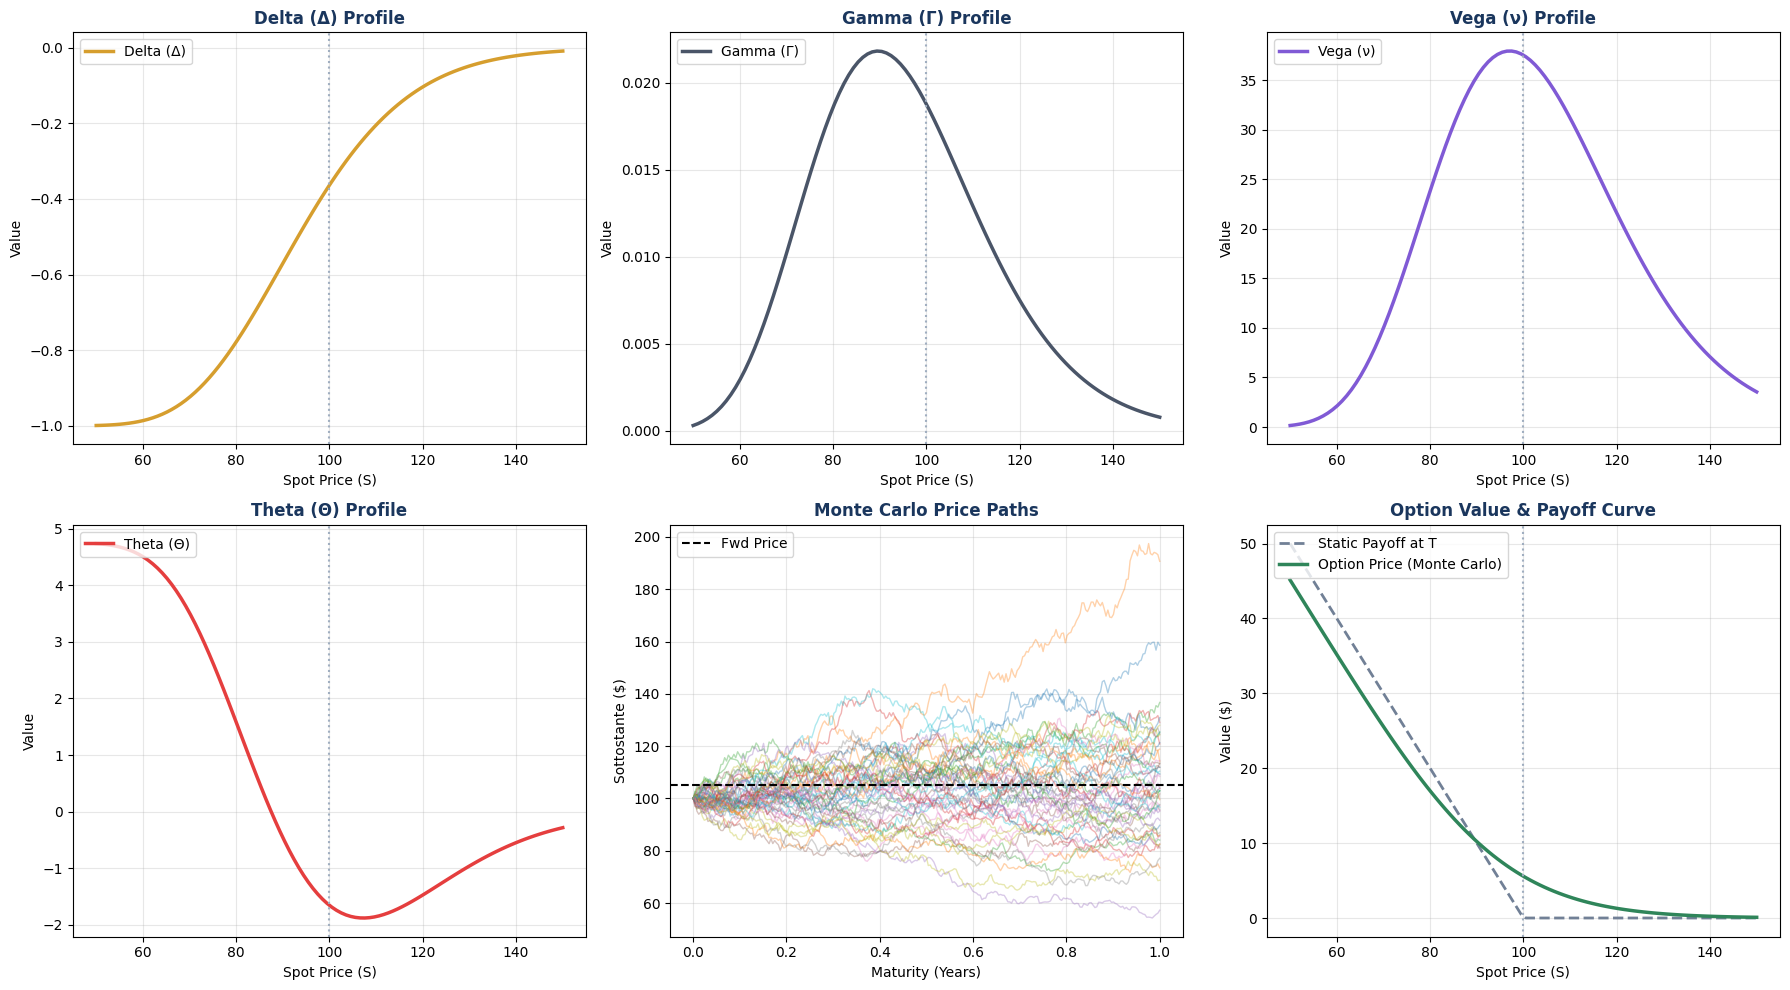

       BARRIER OPTION (DOWN-AND-OUT CALL)
 Market Inputs: S0=100.0, K=100.0, Barrier=85.0, T=1.0Y, r=5.0%
-----------------------------------------------------------------
 Monte Carlo Price   : 9.84611 USD (± 0.15384)



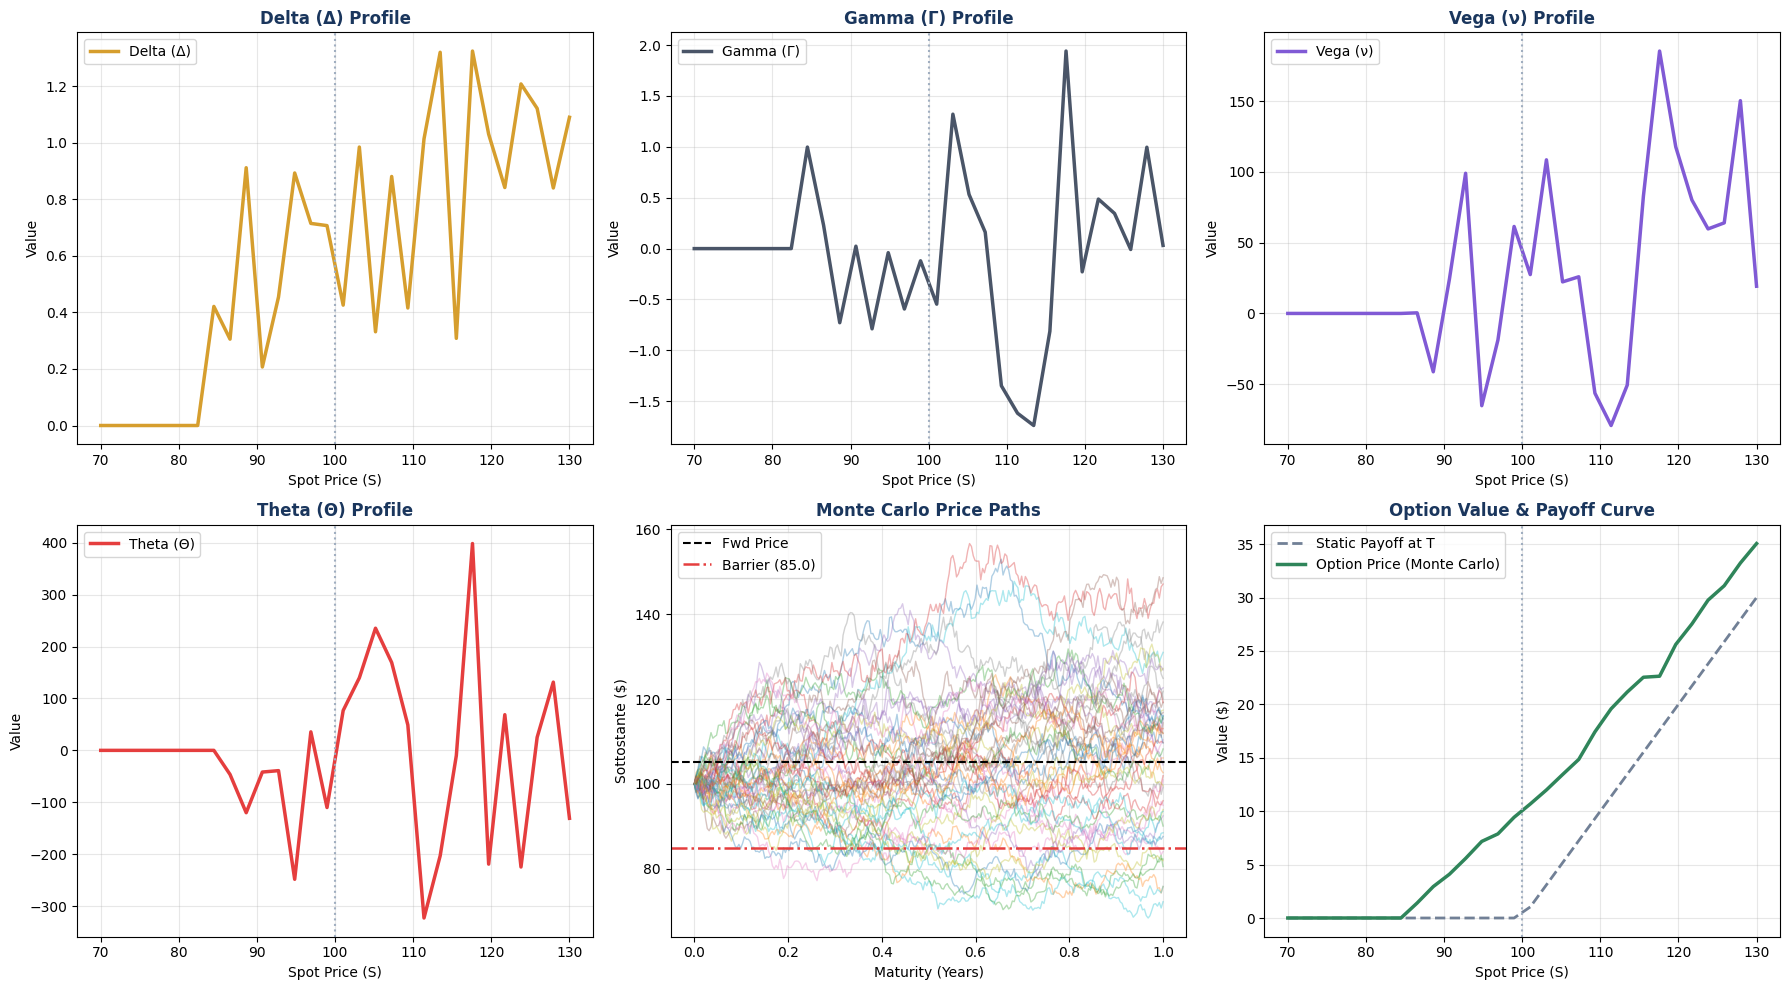

                ASIAN ARITHMETIC CALL
 Monte Carlo Price   : 5.63610 USD



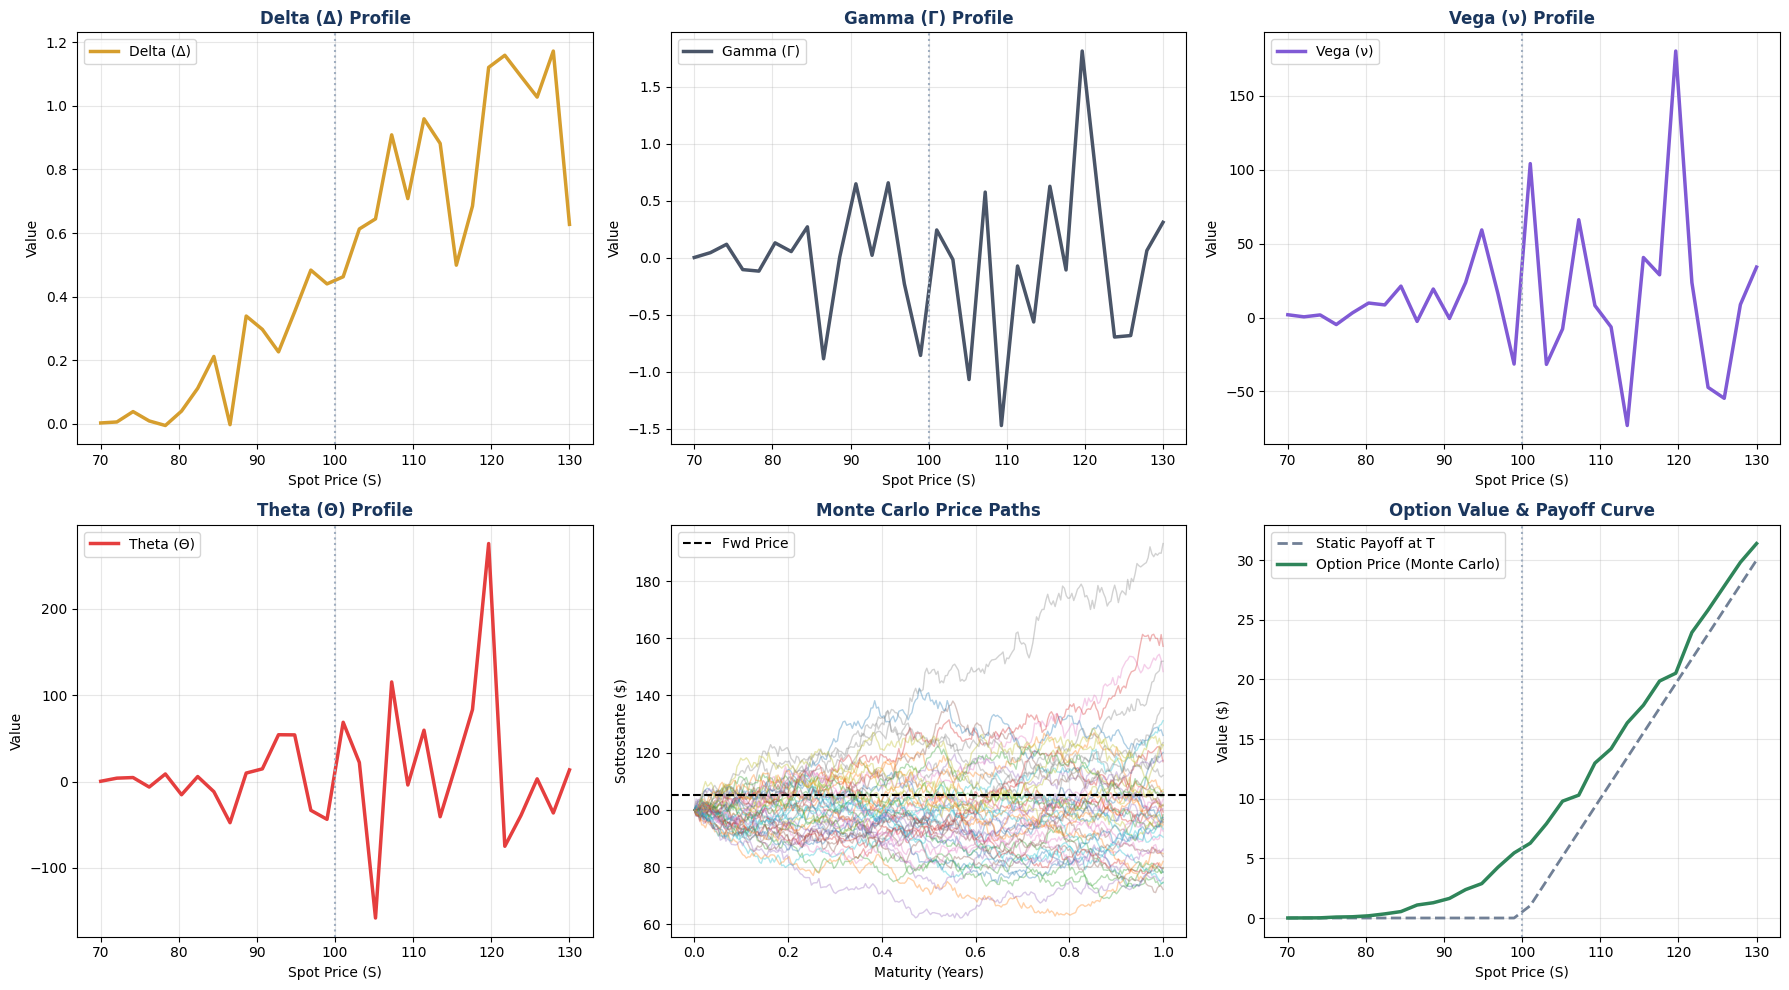

                DIGITAL CASH-OR-NOTHING CALL
 Monte Carlo Price   : 5.38396 USD



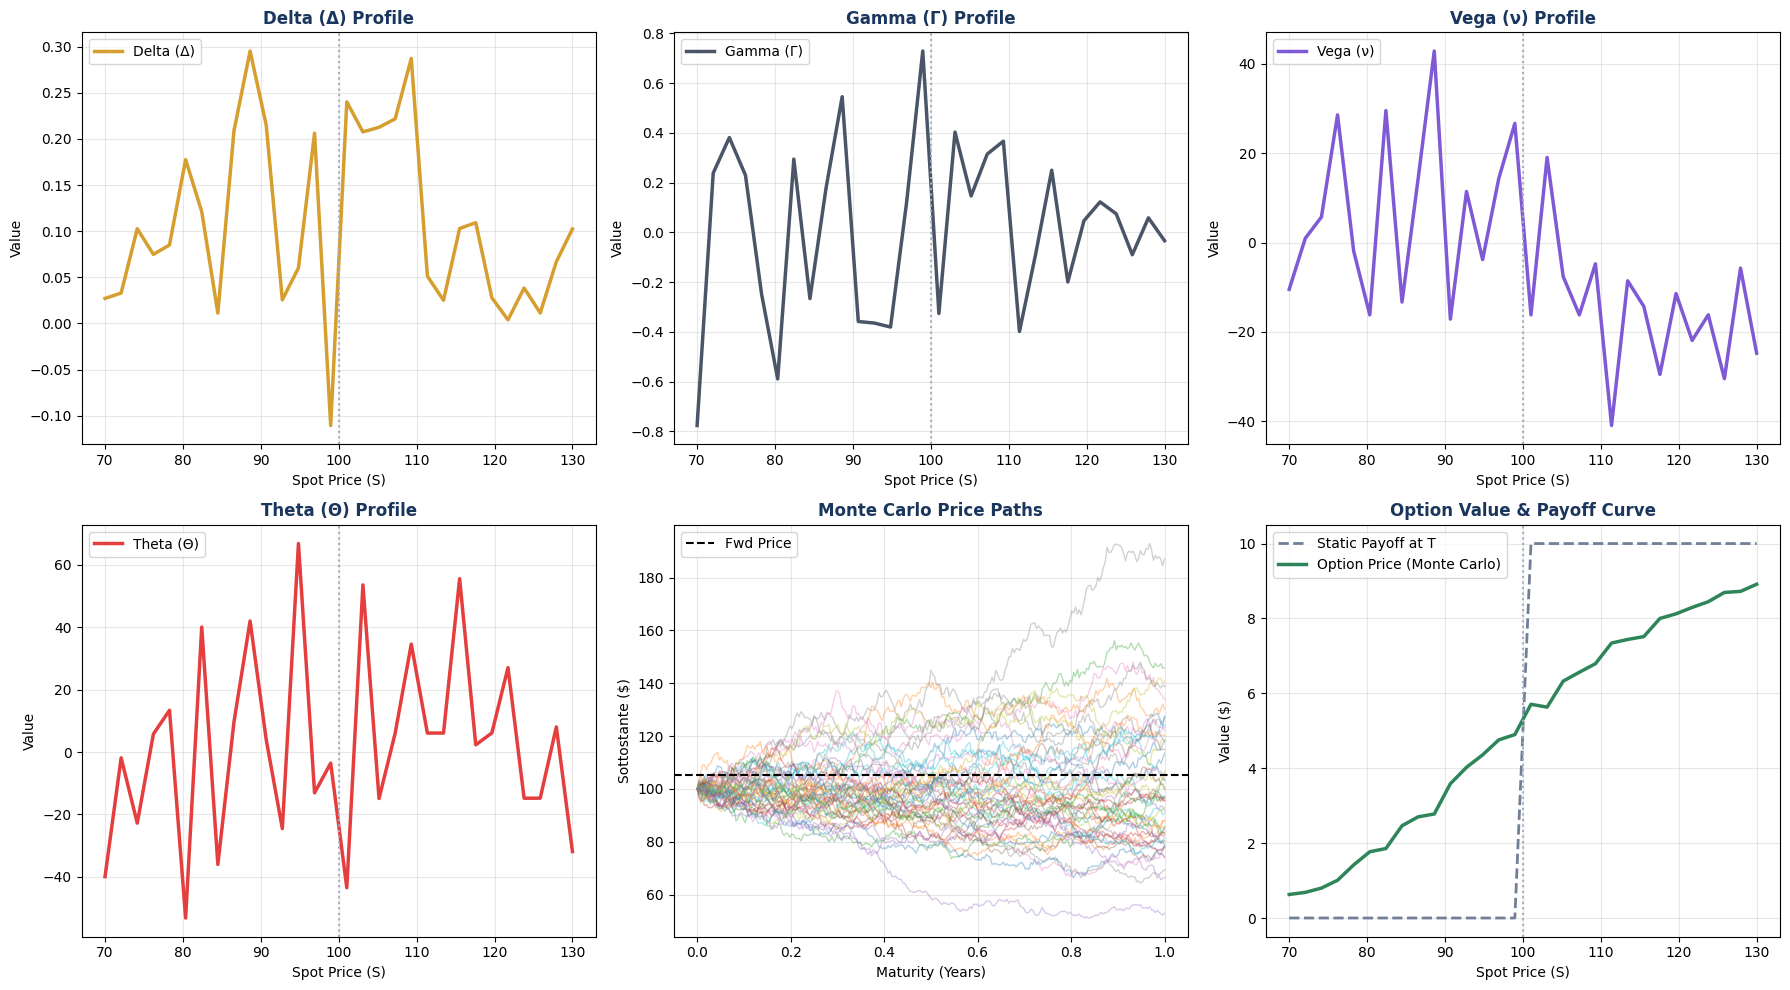

       INTEREST RATE SWAP (PAYER)
 Contract Maturity : 5 Years
 Notional Principal: 10,000,000.00 USD
 Fixed Leg Rate    : 4.5000%
 Index Curve       : QuantLib MultiCurve (USD)
-----------------------------------------------------------------
 Fixed Leg NPV     : 1,962,485.91 USD
 Floating Leg NPV  : 2,045,716.59 USD
-----------------------------------------------------------------
 SWAP NET VALUE    : +83,230.68 USD
 FAIR SWAP RATE    : 4.6908% (Par Rate)
           CREDIT DEFAULT SWAP
 Contract Maturity : 5 Years
 Notional Principal: 5,000,000.00 USD
 Recovery Rate (R) : 40.00%
 Hazard Rate (λ)   : 1.5000% (Constant Intensity)
-----------------------------------------------------------------
 Protection Leg NPV: 193,463.44 USD
 Risk-Free Discount: 4.7005%
-----------------------------------------------------------------
 FAIR CDS SPREAD   : 90.00 bps
 Status: Credit risk premium calibrated using continuous-hazard model.

            CROSS CURRENCY SWAP
 Contract Maturity : 7 Years
 

In [87]:
if __name__ == "__main__":
    try:
        curve_usd = QuantLibMultiCurve(currency="USD")
        curve_usd.fetch_and_build()

        curve_eur = QuantLibMultiCurve(currency="EUR")
        curve_eur.fetch_and_build()
    except NameError:
        print("Error: Make sure the QuantLibMultiCurve class is defined correctly in the code.")
        raise

    S0, K, T, r, sigma = 100.0, 100.0, 1.0, 0.05, 0.20

    call_vanilla = EuropeanCallOption(S0=S0, T=T, r=r, sigma=sigma, K=K, simulations=10000)
    call_vanilla.full_report()
    call_vanilla.plot_greeks_dashboard()

    put_vanilla = EuropeanPutOption(S0=S0, T=T, r=r, sigma=sigma, K=K, simulations=10000)
    put_vanilla.full_report()
    put_vanilla.plot_greeks_dashboard()


    barrier_opt = BarrierOption(
        S0=S0, T=T, r=r, sigma=sigma, K=K,
        barrier=85.0, barrier_direction="down", barrier_style="out",
        option_type="call", simulations=10000
    )
    barrier_opt.full_report()
    barrier_opt.plot_greeks_dashboard()

    asian_opt = AsianOption(S0=S0, T=T, r=r, sigma=sigma, K=K, option_type="call", simulations=10000)
    asian_opt.full_report()
    asian_opt.plot_greeks_dashboard()

    digital_opt = DigitalOption(S0=S0, T=T, r=r, sigma=sigma, K=K, cash_payoff=10.0, option_type="call", simulations=10000)
    digital_opt.full_report()
    digital_opt.plot_greeks_dashboard()


    irs = InterestRateSwap(nominal=10_000_000, maturity=5, fixed_rate=0.045, curve=curve_usd)
    irs.full_report(side="payer")

    cds = CreditDefaultSwap(nominal=5_000_000, maturity=5, recovery_rate=0.40, hazard_rate=0.015, curve=curve_usd)
    cds.full_report()

    ccs = CrossCurrencySwap(
        nominal_eur=10_000_000, fx_spot_eurusd=1.0850, maturity=7,
        rate_eur=0.03, rate_usd=0.042, curve_eur=curve_eur, curve_usd=curve_usd
    )
    ccs.full_report(reporting_currency="EUR")